### imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

### classifier

In [4]:
class SalesAbilityClassifier:
    def __init__(self, data_path='VPTD_Dataset.csv'):
        """
        Initialize the Sales Ability Classifier
        """
        self.data = None
        self.X = None
        self.y = None
        self.models = {}
        self.scaler = StandardScaler()
        self.load_data(data_path)

    def load_data(self, data_path):
        """Load and examine the dataset"""
        try:
            self.data = pd.read_csv(data_path)
            print("Dataset loaded successfully!")
            print(f"Shape: {self.data.shape}")
            print("\nColumn names:")
            print(self.data.columns.tolist())
            print("\nFirst few rows:")
            print(self.data.head())
            print("\nDataset info:")
            print(self.data.info())

            print("\nMissing values:")
            print(self.data.isnull().sum())

        except Exception as e:
            print(f"Error loading data: {e}")
            print("Please make sure 'VPTD_Dataset.csv' is uploaded to your Colab environment")

    def preprocess_data(self):
        """
        Preprocess the data and prepare features
        """
        if self.data is None:
            print("No data loaded. Please load data first.")
            return

        # Identify personality trait columns (Big Five: OCEAN)
        # Common naming conventions: O_, C_, E_, A_, N_ or Openness, Conscientiousness, etc.
        personality_cols = []

        for col in self.data.columns:
            col_lower = col.lower()
            if any(trait in col_lower for trait in ['openness', 'open', 'conscientiousness', 'conscientious',
                                                   'extraversion', 'extroversion', 'agreeableness', 'agreeable',
                                                   'neuroticism', 'neurotic']) or \
               any(col.startswith(prefix) for prefix in ['O_', 'C_', 'E_', 'A_', 'N_']):
                personality_cols.append(col)

        print(f"Identified personality trait columns: {personality_cols}")

        if not personality_cols:
            print("Could not automatically identify personality trait columns.")
            print("Available columns:", self.data.columns.tolist())
            print("Please modify the code to specify the correct column names.")
            return

        sales_cols = []
        for col in self.data.columns:
            col_lower = col.lower()
            if any(term in col_lower for term in ['sales', 'se', 'selling', 'sell']):
                sales_cols.append(col)

        print(f"Identified sales-related columns: {sales_cols}")

        self.X = self.data[personality_cols].copy()

        if 'sales_ability' in self.data.columns:
            self.y = self.data['sales_ability']
        elif any('ground_truth' in col.lower() for col in self.data.columns):
            gt_col = [col for col in self.data.columns if 'ground_truth' in col.lower()][0]
            self.y = self.data[gt_col]
        else:
            if sales_cols:
                sales_col = sales_cols[0]
                self.y = (self.data[sales_col] > self.data[sales_col].median()).astype(int)
                print(f"Created binary target based on median of {sales_col}")
            else:
                print("Could not identify target variable. Please specify manually.")
                return

        print(f"Features shape: {self.X.shape}")
        print(f"Target distribution: {self.y.value_counts()}")

    def create_theory_based_classifier(self):
        """
        Create classification based on the theory:
        Good salesmen have high (O,C,E) and low (A,N)
        """
        if self.X is None:
            print("Please preprocess data first")
            return

        trait_mapping = {
            'O': [],  # Openness
            'C': [],  # Conscientiousness
            'E': [],  # Extraversion
            'A': [],  # Agreeableness
            'N': []   # Neuroticism
        }

        for col in self.X.columns:
            col_lower = col.lower()
            if 'open' in col_lower or col.startswith('O_'):
                trait_mapping['O'].append(col)
            elif 'conscientious' in col_lower or col.startswith('C_'):
                trait_mapping['C'].append(col)
            elif 'extra' in col_lower or col.startswith('E_'):
                trait_mapping['E'].append(col)
            elif 'agreeable' in col_lower or col.startswith('A_'):
                trait_mapping['A'].append(col)
            elif 'neurot' in col_lower or col.startswith('N_'):
                trait_mapping['N'].append(col)

        print("Trait mapping:", trait_mapping)

        trait_scores = {}
        for trait, cols in trait_mapping.items():
            if cols:
                trait_scores[trait] = self.X[cols].mean(axis=1)
            else:
                print(f"Warning: No columns found for trait {trait}")

        if len(trait_scores) >= 3:

            normalized_scores = {}
            for trait, scores in trait_scores.items():
                normalized_scores[trait] = (scores - scores.min()) / (scores.max() - scores.min())

            sales_score = pd.Series(0, index=self.X.index)

            for trait in ['O', 'C', 'E']:
                if trait in normalized_scores:
                    sales_score += normalized_scores[trait]

            for trait in ['A', 'N']:
                if trait in normalized_scores:
                    sales_score -= normalized_scores[trait]

            theory_predictions = (sales_score > sales_score.median()).astype(int)

            return theory_predictions, sales_score

        return None, None

    def train_ml_models(self):
        """
        Train multiple machine learning models
        """
        if self.X is None or self.y is None:
            print("Please preprocess data first")
            return

        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=0.3, random_state=42, stratify=self.y
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        models = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
        }

        results = {}

        for name, model in models.items():
            print(f"\nTraining {name}...")

            if name == 'Logistic Regression':
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                y_pred_train = model.predict(X_train_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_pred_train = model.predict(X_train)

            self.models[name] = model

            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred)

            if name == 'Logistic Regression':
                cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
            else:
                cv_scores = cross_val_score(model, X_train, y_train, cv=5)

            results[name] = {
                'train_accuracy': train_acc,
                'test_accuracy': test_acc,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'predictions': y_pred,
                'y_test': y_test
            }

            print(f"{name} Results:")
            print(f"  Train Accuracy: {train_acc:.3f}")
            print(f"  Test Accuracy: {test_acc:.3f}")
            print(f"  CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

        return results

    def visualize_results(self, ml_results=None, theory_pred=None, theory_scores=None):
        """
        Create comprehensive visualizations
        """
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Sales Ability Classification Analysis', fontsize=16)

        if self.X is not None:
            ax1 = axes[0, 0]
            self.X.boxplot(ax=ax1)
            ax1.set_title('Personality Traits Distribution')
            ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

        if self.y is not None:
            ax2 = axes[0, 1]
            self.y.value_counts().plot(kind='bar', ax=ax2)
            ax2.set_title('Sales Ability Distribution')
            ax2.set_xlabel('Sales Ability Class')

        if self.X is not None and self.y is not None:
            ax3 = axes[0, 2]
            corr_data = pd.concat([self.X, pd.Series(self.y, name='SalesAbility')], axis=1)
            corr_matrix = corr_data.corr()
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
            ax3.set_title('Feature Correlation Matrix')

        if ml_results:
            ax4 = axes[1, 0]
            model_names = list(ml_results.keys())
            test_accs = [ml_results[model]['test_accuracy'] for model in model_names]
            cv_means = [ml_results[model]['cv_mean'] for model in model_names]

            x = np.arange(len(model_names))
            width = 0.35

            ax4.bar(x - width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
            ax4.bar(x + width/2, cv_means, width, label='CV Mean', alpha=0.8)
            ax4.set_xlabel('Models')
            ax4.set_ylabel('Accuracy')
            ax4.set_title('Model Performance Comparison')
            ax4.set_xticks(x)
            ax4.set_xticklabels(model_names)
            ax4.legend()

        if theory_pred is not None and self.y is not None:
            ax5 = axes[1, 1]
            conf_matrix = confusion_matrix(self.y, theory_pred)
            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax5)
            ax5.set_title('Theory-based Classification\nConfusion Matrix')
            ax5.set_xlabel('Predicted')
            ax5.set_ylabel('Actual')

        if theory_scores is not None:
            ax6 = axes[1, 2]
            ax6.hist(theory_scores, bins=30, alpha=0.7, edgecolor='black')
            ax6.axvline(theory_scores.median(), color='red', linestyle='--',
                       label=f'Median: {theory_scores.median():.2f}')
            ax6.set_title('Theory-based Sales Score Distribution')
            ax6.set_xlabel('Sales Score')
            ax6.set_ylabel('Frequency')
            ax6.legend()

        plt.tight_layout()
        plt.show()

        if ml_results and 'Random Forest' in self.models:
            plt.figure(figsize=(10, 6))
            rf_model = self.models['Random Forest']
            feature_importance = pd.DataFrame({
                'feature': self.X.columns,
                'importance': rf_model.feature_importances_
            }).sort_values('importance', ascending=True)

            plt.barh(feature_importance['feature'], feature_importance['importance'])
            plt.xlabel('Feature Importance')
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

    def compare_with_self_estimation(self, se_column=None):
        """
        Compare predictions with self-estimation
        """
        if se_column and se_column in self.data.columns:
            se_data = self.data[se_column]

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))

            axes[0].scatter(se_data, self.y, alpha=0.6)
            axes[0].set_xlabel('Self-Estimated Sales Ability')
            axes[0].set_ylabel('Ground Truth Sales Ability')
            axes[0].set_title('Self-Estimation vs Ground Truth')

            correlation = se_data.corr(self.y)
            axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}',
                        transform=axes[0].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            axes[1].hist(se_data, bins=20, alpha=0.5, label='Self-Estimation', density=True)
            axes[1].hist(self.y, bins=20, alpha=0.5, label='Ground Truth', density=True)
            axes[1].set_xlabel('Sales Ability Score')
            axes[1].set_ylabel('Density')
            axes[1].set_title('Distribution Comparison')
            axes[1].legend()

            plt.tight_layout()
            plt.show()
        else:
            print(f"Column {se_column} not found. Available columns: {self.data.columns.tolist()}")

### main

=== Sales Ability Classification System ===

Dataset loaded successfully!
Shape: (38, 7)

Column names:
['Id_name', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness', 'SE']

First few rows:
       Id_name  Extraversion  Agreeableness  Conscientiousness  Neuroticism  \
0  wzewmMk_Nzv          0.56           0.55               0.67         0.62   
1  MKdgEMd_con          0.72           0.85               0.77         0.27   
2  pjlESEZ_rgA          0.56           0.68               0.83         0.45   
3  HmakBQy_Zuo          0.64           0.52               0.80         0.32   
4  PMoGeaZ_lek          0.65           0.71               0.67         0.48   

   Openness  SE  
0      0.59   2  
1      0.70   4  
2      0.67   3  
3      0.65   4  
4      0.68   2  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------

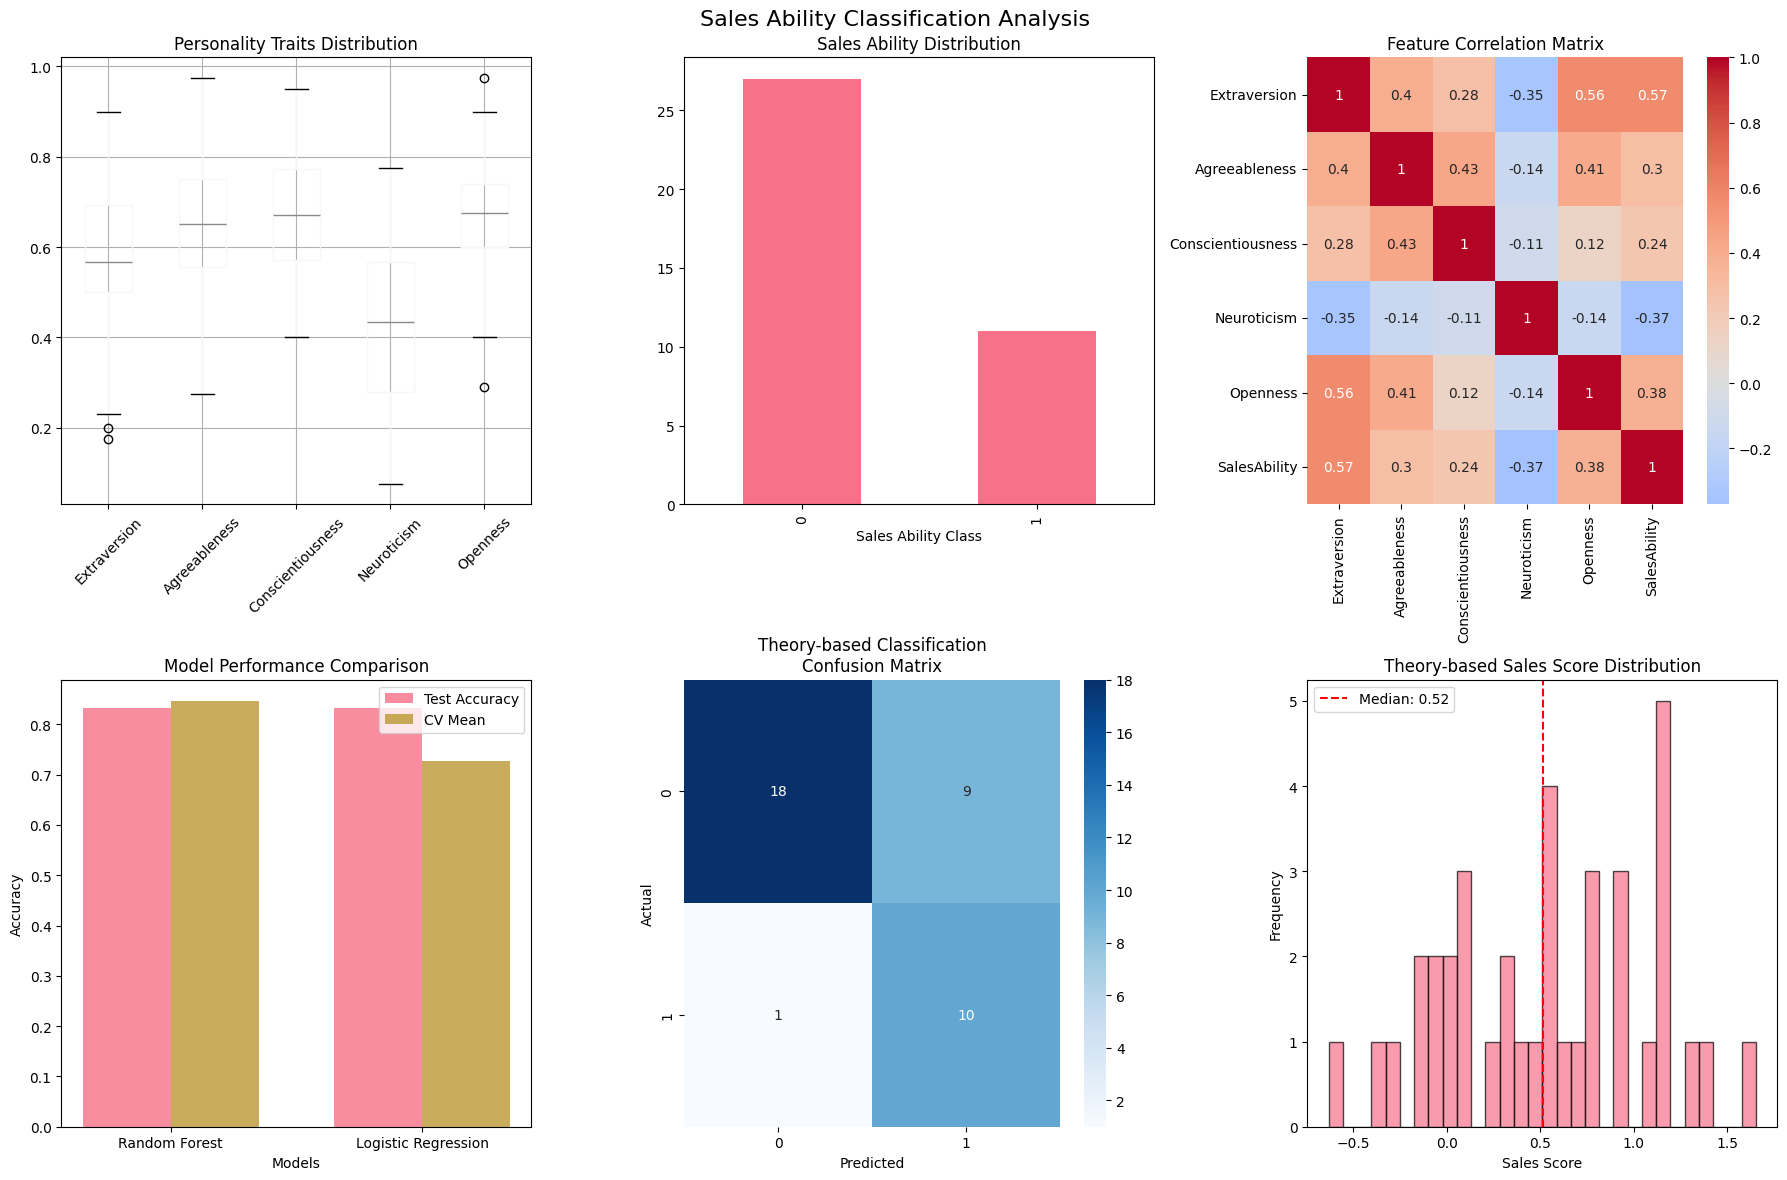

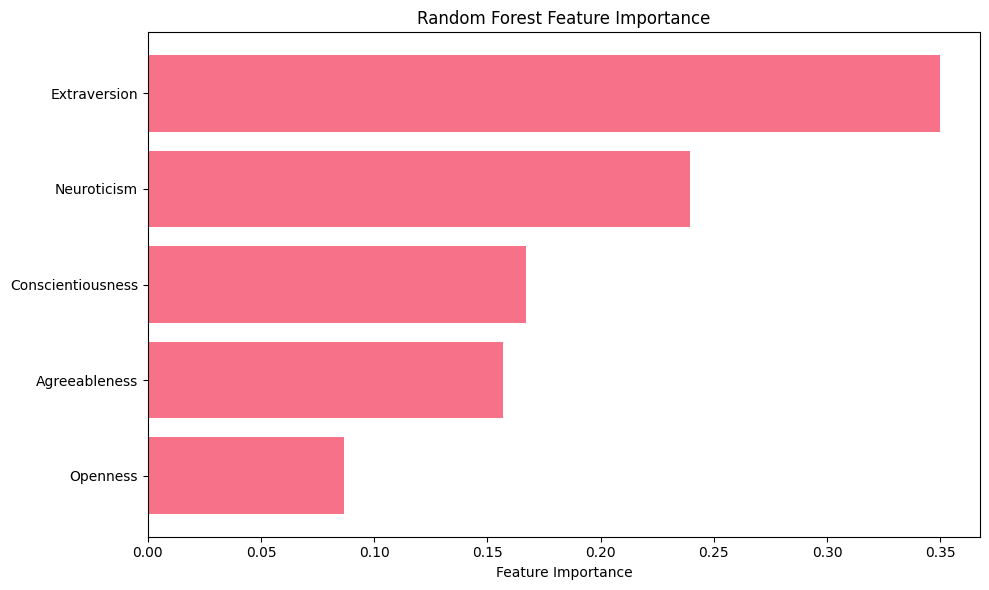


=== Self-Estimation Comparison ===


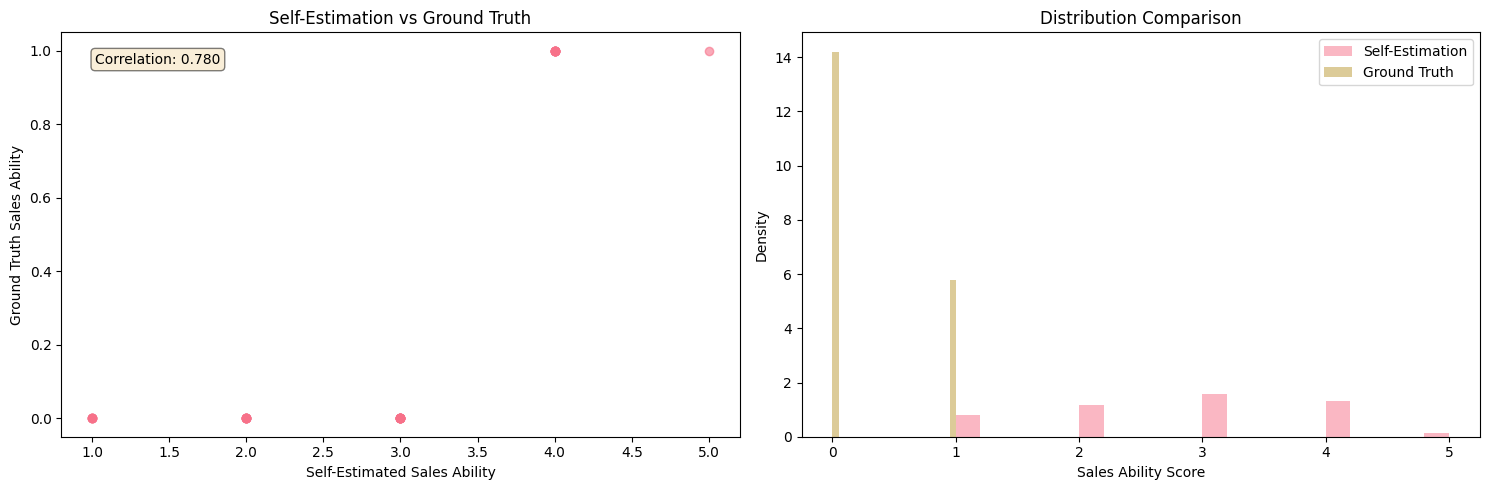


=== Analysis Complete ===


In [5]:
def main():
    print("=== Sales Ability Classification System ===\n")
    classifier = SalesAbilityClassifier()
    if classifier.data is not None:
        print("\n=== Preprocessing Data ===")
        classifier.preprocess_data()

        if classifier.X is not None and classifier.y is not None:
            print("\n=== Theory-based Classification ===")
            theory_pred, theory_scores = classifier.create_theory_based_classifier()

            if theory_pred is not None:
                theory_accuracy = accuracy_score(classifier.y, theory_pred)
                print(f"Theory-based Classification Accuracy: {theory_accuracy:.3f}")
                print("\nTheory-based Classification Report:")
                print(classification_report(classifier.y, theory_pred))

            print("\n=== Machine Learning Models ===")
            ml_results = classifier.train_ml_models()

            print("\n=== Visualization ===")
            classifier.visualize_results(ml_results, theory_pred, theory_scores)

            print("\n=== Self-Estimation Comparison ===")
            se_cols = [col for col in classifier.data.columns if 'se' in col.lower() or 'self' in col.lower()]
            if se_cols:
                classifier.compare_with_self_estimation(se_cols[0])
            else:
                print("No self-estimation column found automatically.")
                print("Available columns:", classifier.data.columns.tolist())

    print("\n=== Analysis Complete ===")


if __name__ == "__main__":
    main()